In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import nltk
from collections import Counter
import re

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
from datasets import load_dataset

csv_file_path = '/content/drive/MyDrive/2025-26/NLP/dancing1000v2.csv'

df = pd.read_csv(csv_file_path)

dancing_dataset = load_dataset('csv', data_files=csv_file_path)

display(df.head())
df.info()

Generating train split: 0 examples [00:00, ? examples/s]

,Unnamed: 0,id,name,album_name,artists,danceability,energy,key,loudness,mode,...,tempo,duration_ms,lyrics,year,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres
0,186517,3MJhPqL2IgGs7gHEB2M35q,Hard to Love,BORN PINK,"[""BLACKPINK""]",0.654,0.768,5,-5.007,1,...,104.970,162570,Ain't no magic tool to fix it\nYou should keep...,2022,Pop,63,56782207,82.0,"[""41MozSoPIsD1dJM0CLPjZF""]","[""k-pop""]"
1,405723,28xiVJLGLwEHNFDzXKUIdY,Slave to Love,Slave to Love,"[""BossArt Ensemble"", ""Marvin""]",0.835,0.378,2,-13.510,0,...,125.023,211192,Tell her I'll be waiting\nIn the usual place\n...,2020,Jazz,54,6877,48.0,"[""3OvwaCrQZ9yTmwuQdwHOM1"", ""1vS37gXPQ5Ne8eDbFz...","[""bossa nova"", ""latin jazz"", ""lounge""]"
2,71446,6Kx3xYdwtO1qF9ZuUEj7JG,Bunny Hop,Entourage 2,"[""Da Entourage""]",0.800,0.846,1,-6.005,1,...,94.502,236080,Da-da-da-da-da-da-da\nDa-da-da-da-da-da-da\n\n...,2003,Hip-Hop,45,2549,28.0,"[""4vqML5L33geHYWYQpOcZLW""]","[""bounce"", ""new orleans bounce"", ""zydeco""]"
3,67429,64UJ810pLNwurMLRCPJPoa,Breaking Up Is Hard to Do,Neil Sedaka Sings The Hits,"[""Neil Sedaka""]",0.742,0.663,8,-7.590,0,...,116.603,136093,"To do do, down dooby doo down down\nComma comm...",1999,Pop,42,591908,56.0,"[""5N6GwJzOcOY5kv8p0NjhYL""]","[""adult standards"", ""doo-wop""]"
4,45364,3nyGl8ETgMrL9vXxG81VWy,Banana Bread,Cavetown,"[""Cavetown""]",0.706,0.503,3,-10.329,1,...,119.959,289762,You're falling further down but I've got you b...,2015,Pop,40,4471483,69.0,"[""2hR4h1Cao2ueuI7Cx9c7V8""]","[""bedroom pop""]"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              1000 non-null   int64  
 1   id                      1000 non-null   object 
 2   name                    1000 non-null   object 
 3   album_name              1000 non-null   object 
 4   artists                 1000 non-null   object 
 5   danceability            1000 non-null   float64
 6   energy                  1000 non-null   float64
 7   key                     1000 non-null   int64  
 8   loudness                1000 non-null   float64
 9   mode                    1000 non-null   int64  
 10  speechiness             1000 non-null   float64
 11  acousticness            1000 non-null   float64
 12  instrumentalness        1000 non-null   float64
 13  liveness                1000 non-null   float64
 14  valence                 1000 non-null   f

In [5]:
danceable_df = df[df['danceability'] > 0.6]
non_danceable_df = df[df['danceability'] < 0.4]

print(f"Number of danceable tracks: {len(danceable_df)}")
print(f"Number of non-danceable tracks: {len(non_danceable_df)}")

def get_most_common_words(dataframe, text_column, num_words=10):
    all_words = []
    stop_words = set(stopwords.words('english'))

    if text_column not in dataframe.columns:
        print(f"Warning: Column '{text_column}' not found in DataFrame.")
        return Counter()

    for text in dataframe[text_column].dropna():
        words = re.findall(r'\b\w+\b', text.lower())
        filtered_words = [word for word in words if word not in stop_words and len(word) > 1]
        all_words.extend(filtered_words)

    return Counter(all_words).most_common(num_words)

Number of danceable tracks: 500
Number of non-danceable tracks: 500


In [6]:
common_words_danceable_raw = get_most_common_words(danceable_df, 'name', 30)
common_words_non_danceable_raw = get_most_common_words(non_danceable_df, 'name', 30)

words_danceable_set = {word for word, count in common_words_danceable_raw}
words_non_danceable_set = {word for word, count in common_words_non_danceable_raw}

words_in_common = words_danceable_set.intersection(words_non_danceable_set)

common_words_danceable_filtered = [(word, count) for word, count in common_words_danceable_raw if word not in words_in_common]
common_words_non_danceable_filtered = [(word, count) for word, count in common_words_non_danceable_raw if word not in words_in_common]

print("Most common words unique to danceable track names:")
for word, count in common_words_danceable_filtered:
    print(f"- {word}: {count}")

print("\n" + "-" * 50 + "\n")

print("Most common words unique to non-danceable track names:")
for word, count in common_words_non_danceable_filtered:
    print(f"- {word}: {count}")

print("\n" + "-" * 50 + "\n")

print("Words found in both danceable and non-danceable track names:")
for word in words_in_common:
    print(f"- {word}")

Most common words unique to danceable track names:
- remix: 20
- like: 9
- edit: 8
- radio: 8
- good: 8
- girl: 6
- back: 5
- let: 5
- woman: 4
- rock: 4
- gone: 4
- new: 4
- ready: 4
- mine: 4
- heart: 4
- dream: 4
- last: 4

--------------------------------------------------

Most common words unique to non-danceable track names:
- live: 26
- christmas: 6
- god: 5
- get: 5
- little: 5
- go: 5
- take: 4
- world: 4
- right: 4
- sky: 4
- dark: 4
- great: 4
- blue: 4
- london: 3
- 2002: 3
- living: 3
- reason: 3

--------------------------------------------------

Words found in both danceable and non-danceable track names:
- version
- time
- home
- feat
- love
- away
- life
- mix
- remastered
- remaster
- song
- one
- night


In [7]:
if common_words_danceable_filtered:
    total_length_danceable = sum(len(word) for word, count in common_words_danceable_filtered)
    avg_length_danceable = total_length_danceable / len(common_words_danceable_filtered)
    print(f"\nAverage word length for unique danceable track names: {avg_length_danceable:.2f}")
else:
    print("\nNo unique danceable words to analyze for length.")

if common_words_non_danceable_filtered:
    total_length_non_danceable = sum(len(word) for word, count in common_words_non_danceable_filtered)
    avg_length_non_danceable = total_length_non_danceable / len(common_words_non_danceable_filtered)
    print(f"Average word length for unique non-danceable track names: {avg_length_non_danceable:.2f}")
else:
    print("No unique non-danceable words to analyze for length.")


Average word length for unique danceable track names: 4.24
Average word length for unique non-danceable track names: 4.65


In [8]:
if 'lyrics' in danceable_df.columns and not danceable_df['lyrics'].empty:
    danceable_df['lyric_length'] = danceable_df['lyrics'].astype(str).apply(len)
    avg_lyric_length_danceable = danceable_df['lyric_length'].mean()
    print(f"\nAverage lyric length for danceable tracks: {avg_lyric_length_danceable:.2f}")
else:
    print("\nNo lyrics data for danceable tracks to analyze.")

if 'lyrics' in non_danceable_df.columns and not non_danceable_df['lyrics'].empty:
    non_danceable_df['lyric_length'] = non_danceable_df['lyrics'].astype(str).apply(len)
    avg_lyric_length_non_danceable = non_danceable_df['lyric_length'].mean()
    print(f"Average lyric length for non-danceable tracks: {avg_lyric_length_non_danceable:.2f}")
else:
    print("No lyrics data for non-danceable tracks to analyze.")


Average lyric length for danceable tracks: 1757.43
Average lyric length for non-danceable tracks: 1116.62


/tmp/ipykernel_29244/4106627872.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  danceable_df['lyric_length'] = danceable_df['lyrics'].astype(str).apply(len)
/tmp/ipykernel_29244/4106627872.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_danceable_df['lyric_length'] = non_danceable_df['lyrics'].astype(str).apply(len)


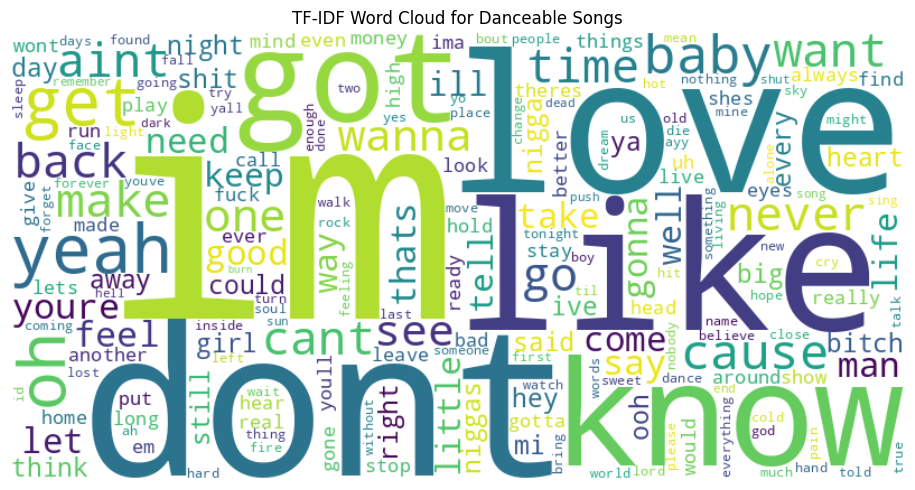

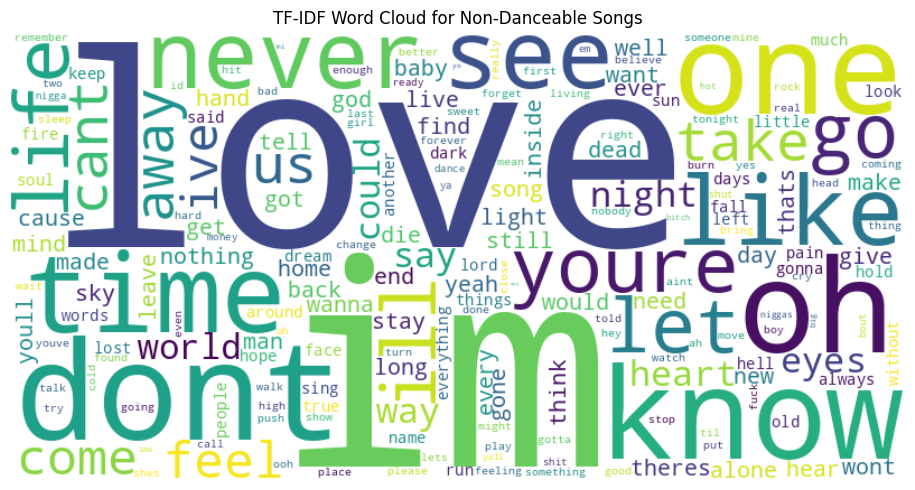

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    stop_words = set(stopwords.words('english'))
    filtered_words = [word for word in words if word not in stop_words and len(word) > 1]
    return ' '.join(filtered_words)

danceable_df_processed = danceable_df.copy()
danceable_df_processed.loc[:, 'cleaned_lyrics'] = danceable_df_processed['lyrics'].apply(preprocess_text)

non_danceable_df_processed = non_danceable_df.copy()
non_danceable_df_processed.loc[:, 'cleaned_lyrics'] = non_danceable_df_processed['lyrics'].apply(preprocess_text)

all_cleaned_lyrics_combined = pd.concat([danceable_df_processed['cleaned_lyrics'], non_danceable_df_processed['cleaned_lyrics']])
tfidf_vectorizer = TfidfVectorizer(max_features=200)

tfidf_vectorizer.fit(all_cleaned_lyrics_combined)

tfidf_matrix_danceable = tfidf_vectorizer.transform(danceable_df_processed['cleaned_lyrics'])
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_scores_danceable = tfidf_matrix_danceable.sum(axis=0).tolist()[0]
tfidf_dict_danceable = dict(zip(feature_names, tfidf_scores_danceable))

tfidf_matrix_non_danceable = tfidf_vectorizer.transform(non_danceable_df_processed['cleaned_lyrics'])
tfidf_scores_non_danceable = tfidf_matrix_non_danceable.sum(axis=0).tolist()[0]
tfidf_dict_non_danceable = dict(zip(feature_names, tfidf_scores_non_danceable))

wordcloud_danceable = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(tfidf_dict_danceable)
wordcloud_non_danceable = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(tfidf_dict_non_danceable)


plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_danceable, interpolation='bilinear')
plt.title('TF-IDF Word Cloud for Danceable Songs')
plt.axis('off')
plt.tight_layout()
plt.savefig('tfidf_wordcloud_danceablenew.png')

plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_non_danceable, interpolation='bilinear')
plt.title('TF-IDF Word Cloud for Non-Danceable Songs')
plt.axis('off')
plt.tight_layout()
plt.savefig('tfidf_wordcloud_non_danceablenew.png')
plt.show()


Number of tracks in high danceability bin (0.9-1.0): 85
Number of tracks in low danceability bin (0.0-0.1): 33


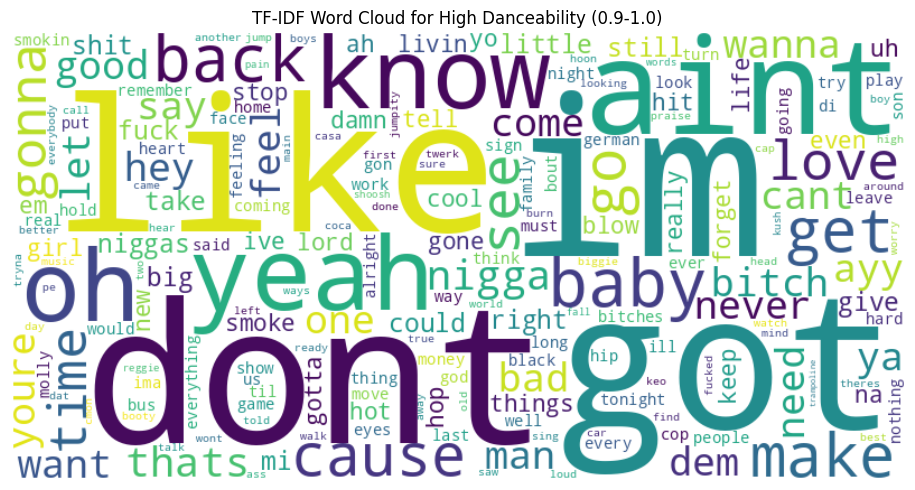

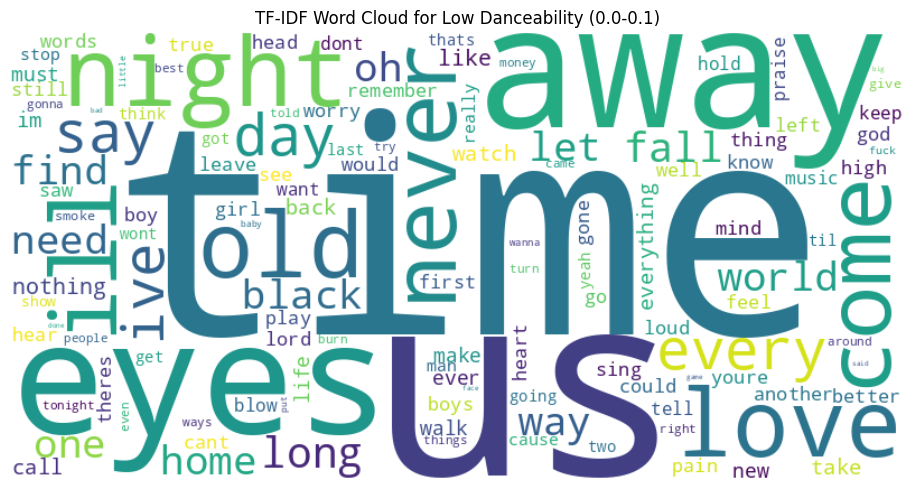

In [10]:
high_danceability_df = df[(df['danceability'] >= 0.8) & (df['danceability'] <= 1.0)].copy()
low_danceability_df = df[(df['danceability'] >= 0.0) & (df['danceability'] <= 0.2)].copy()

print(f"Number of tracks in high danceability bin (0.9-1.0): {len(high_danceability_df)}")
print(f"Number of tracks in low danceability bin (0.0-0.1): {len(low_danceability_df)}")

high_danceability_df.loc[:, 'cleaned_lyrics'] = high_danceability_df['lyrics'].apply(preprocess_text)
low_danceability_df.loc[:, 'cleaned_lyrics'] = low_danceability_df['lyrics'].apply(preprocess_text)

all_cleaned_lyrics_new_bins_combined = pd.concat([
    high_danceability_df['cleaned_lyrics'],
    low_danceability_df['cleaned_lyrics']
])

tfidf_vectorizer_new = TfidfVectorizer(max_features=200)
tfidf_vectorizer_new.fit(all_cleaned_lyrics_new_bins_combined)
feature_names_new = tfidf_vectorizer_new.get_feature_names_out()

tfidf_matrix_high_danceability = tfidf_vectorizer_new.transform(high_danceability_df['cleaned_lyrics'])
tfidf_scores_high_danceability = tfidf_matrix_high_danceability.sum(axis=0).tolist()[0]
tfidf_dict_high_danceability = dict(zip(feature_names_new, tfidf_scores_high_danceability))

tfidf_matrix_low_danceability = tfidf_vectorizer_new.transform(low_danceability_df['cleaned_lyrics'])
tfidf_scores_low_danceability = tfidf_matrix_low_danceability.sum(axis=0).tolist()[0]
tfidf_dict_low_danceability = dict(zip(feature_names_new, tfidf_scores_low_danceability))

wordcloud_high_danceability = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(tfidf_dict_high_danceability)
wordcloud_low_danceability = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(tfidf_dict_low_danceability)


plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_high_danceability, interpolation='bilinear')
plt.title('TF-IDF Word Cloud for High Danceability (0.9-1.0)')
plt.axis('off')
plt.tight_layout()
plt.savefig('tfidf_wordcloud_high_danceabilitynew.png')
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_low_danceability, interpolation='bilinear')
plt.title('TF-IDF Word Cloud for Low Danceability (0.0-0.1)')
plt.axis('off')
plt.tight_layout()
plt.savefig('tfidf_wordcloud_low_danceabilitynew.png')
plt.show()
